[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/notebook.ipynb)

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Download Github files

In [2]:
try:
    import google.colab
    %mkdir data
    %mkdir scripts
    %mkdir results
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/data/INA_dataset.json -O data/INA_dataset.json
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/models.py -O scripts/models.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/utils.py -O scripts/utils.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/embedding.py -O scripts/embedding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/cv_folding.py -O scripts/cv_folding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/configure.py -O scripts/configure.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/plotting.py -O scripts/plotting.py
    print("Working on Colab!")
except:
    print("Not Working on Colab ... or cannot dwnload Githb files!")
    pass

Not Working on Colab ... or cannot dwnload Githb files!


## Load dataset

In [ ]:
import sys, os
sys.path.append('.')
from scripts.utils import Settings

DATA_PATH = "data" # "your-path-to-data"
dataset = "MIMIC"
if dataset == "INA":
    datafile =  "INA_dataset.json"
    target_var = "is_alive?"
    evfields = ['code_descr']
    static_vars = ["gender", "age_group", "primary_disease"]
    disease_list = ["SCD", "CHA", "NHOC", "AS", "AHD", "NTDT", "IM", "TDT", "OD"]
    remove_events = ['followup', 'platelet_change', 'bmi_change', 'thrombosys']
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "MIMIC_dataset.json"
    static_vars = ["gender", "age_at_splenectomy", "primary_disease"]
    disease_list = ["OD", "CHA", "SP", "THA", "AHD", "SCD"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug']
    thresh = 0.3
else:
    raise Exception("dataset not supported!")

class settings:
  def __init__(self, datafile):
    self.dataset = pd.read_json(datafile)
    self.pathology_field = 'primary_disease'
    self.static_vars= static_vars
    self.target_var = target_var
    self.evfields = evfields
    self.remove_events = remove_events
    self.enable_plot=True
    self.n_splits=5
    self.num_epochs=10
    self.batch_size = 16
    self.embedding_dim=128
    self.hidden_dim=300
    self.random_state=42
    self.iter=5
    self.results_dir="results"

args = settings(os.path.join(DATA_PATH, datafile))
args.dataset.head(20)

,gender,is_splenectomized?,splenectomy_indication,splenectomy_response,splenectomy_method,primary_disease,primary_pathology,smoking,dyslipidemia,genotype_beta1,...,bmi,tsh,is_alive?,cause_of_death,date_of_death,birth_date,eventi_infettivi,id,events,age_group
0,M,YES,None,None,Complete laparotomy,"SCD - (Sickle Cell Disease, Anemia/Sickle Cell...",( S/S ),None,None,n/a,...,None,None,YES,n/a,NaT,2138-08-22,1,1,"[{'type': 'surgical_operation', 'event': 'sple...",pediatric
1,F,YES,None,None,Complete laparoscopy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2117-12-30,0,2,"[{'type': 'surgical_operation', 'event': 'sple...",pediatric
2,M,YES,None,None,Complete laparoscopy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2117-05-31,0,3,"[{'type': 'therapy', 'event': 'antibiotic', 'd...",pediatric
3,F,YES,None,None,Complete laparoscopy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2125-04-26,0,4,"[{'type': 'vaccination', 'event': 'vaccine Hib...",pediatric
4,M,YES,None,None,Complete laparotomy,Non-Hemato-Oncological Causes,Trauma,None,None,n/a,...,None,None,YES,n/a,NaT,2139-07-01,0,5,"[{'type': 'therapy', 'event': 'anticoagulant',...",pediatric
5,M,NO,n/a,n/a,n/a,Asplenic Syndromes,Isomerismi,None,None,n/a,...,None,None,None,n/a,NaT,2133-08-02,0,6,"[{'type': 'therapy', 'event': 'anticoagulant',...",None
6,F,YES,None,None,Complete laparotomy,Autoimmune Hematological Diseases,ITP (Idiopathic Thrombocytopenic Purpura),None,None,n/a,...,None,None,YES,n/a,NaT,2118-01-24,0,7,"[{'type': 'surgical_operation', 'event': 'sple...",pediatric
7,F,YES,None,None,Complete laparotomy,Non-Hemato-Oncological Causes,Trauma,None,None,n/a,...,None,None,YES,n/a,NaT,2134-03-01,0,8,"[{'type': 'therapy', 'event': 'anticoagulant',...",pediatric
8,M,YES,None,None,Complete laparotomy,"SCD - (Sickle Cell Disease, Anemia/Sickle Cell...",( S/S ),None,None,n/a,...,None,None,YES,n/a,NaT,2137-08-01,0,9,"[{'type': 'vaccination', 'event': 'vaccine Pne...",pediatric
9,M,YES,None,None,Complete laparotomy,Congenital Hemolytic Anemias,HS (Hereditary Spherocytosis),None,None,n/a,...,None,None,YES,n/a,NaT,2099-04-27,0,10,"[{'type': 'therapy', 'event': 'anticoagulant',...",adolescent


### Plot dataset distributions

<Figure size 640x480 with 0 Axes>

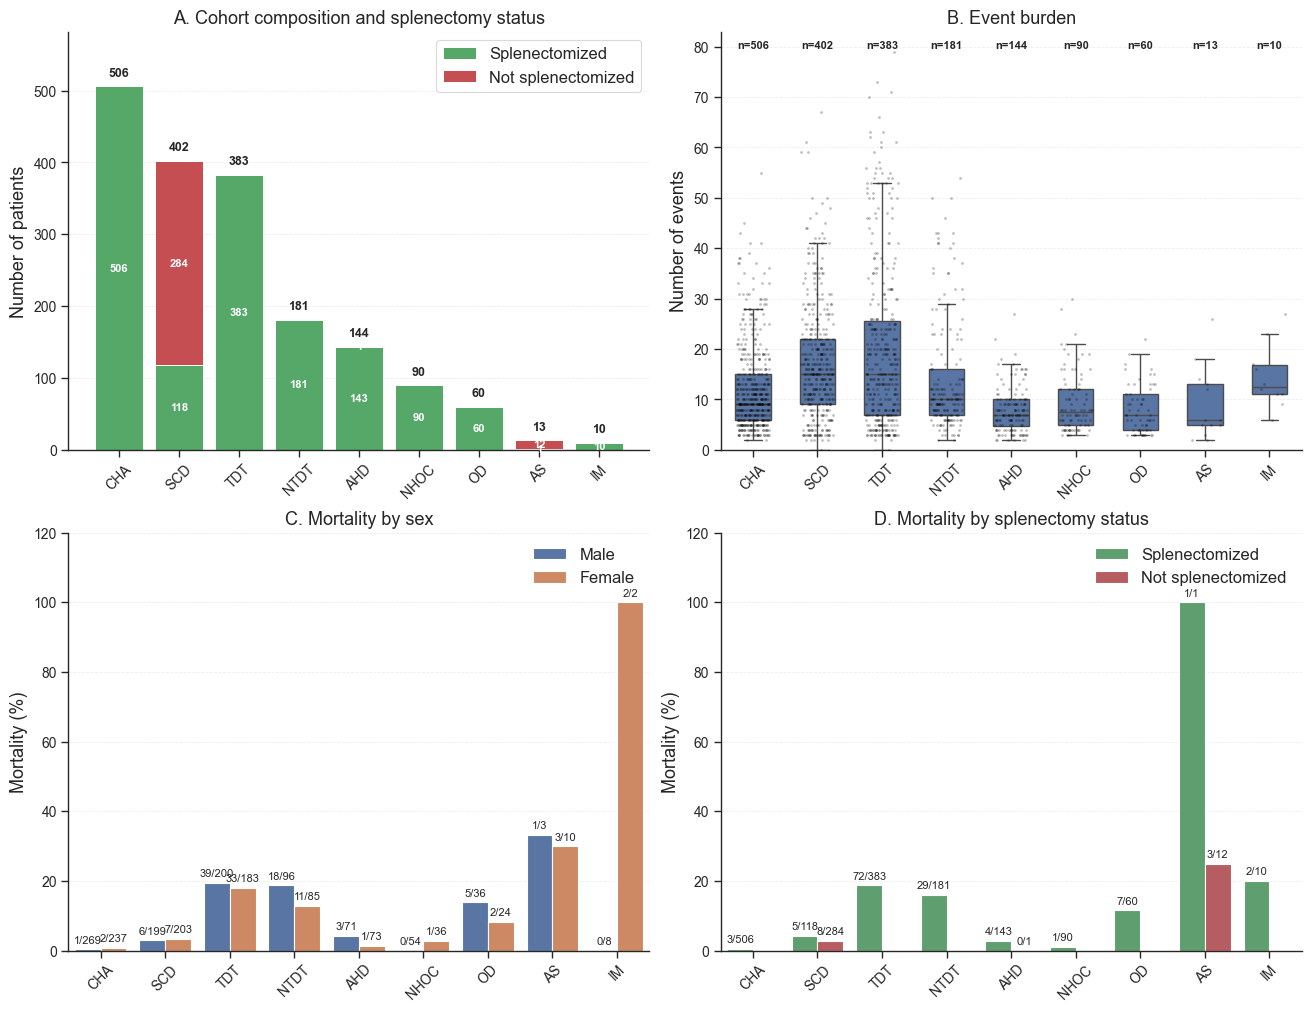

In [5]:
from scripts.plotting import plot_distrib
fig = plot_distrib(args.dataset, dict(zip(list(args.dataset["primary_disease"].unique()), disease_list)))

### Select splenectomize patients

In [6]:
args.dataset = args.dataset[args.dataset["is_splenectomized?"] == 'YES']
args.selected_patient_ids = args.dataset.index
print("Splenectomized Patients no:", len(args.selected_patient_ids))

Splenectomized Patients no: 1492


### Remove patients with specific cause of death

In [7]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 1487


### Remove patients with no events

In [8]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 1486


## Get clinical trajectories

In [9]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), 
    event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 

### Remove events by types

In [10]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")

n.1486 Patients


In [11]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
event_sequences_type = { id: events for (id,events) in event_sequences_type.items() if len(events) > 0 }
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### count event by type and cardinality

In [12]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
surgical_operation,14,1561,"{Destruction of liver, percutaneous approach, ..."
therapy,39,4998,"{Introduction of antihistamine agent, Introduc..."
vaccination,9,6548,"{Meningococcal conjugate vaccine, serogroups A..."
infection,71,555,"{Pneumonia / bronchopneumonia, Infectious mono..."
comorbidity,241,830,"{Blindness, both eyes, Gilbert's syndrome, Oth..."


## Get static variables

In [13]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,primary_disease
0,0,0,0
1,1,0,1
2,0,0,1
3,1,0,1
4,0,0,2
...,...,...,...
1784,1,0,1
1785,1,0,1
1786,1,2,1
1787,1,0,0


## Get targets

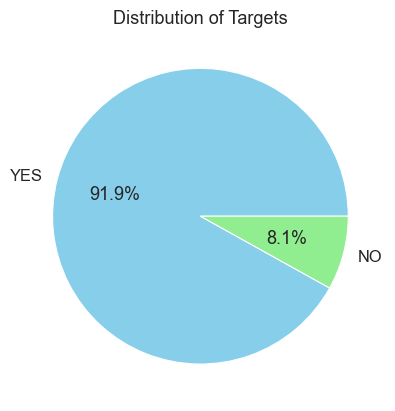

In [14]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(os.path.join(DATA_PATH, f"{dataset}_targets.csv"))
plt.show()

In [15]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, event_sequences_type, target_df.to_dict(), X_static, args)

# Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

## Validation (Iterated 5-fold)

In [16]:
import pickle
from scripts.cv_folding import lgbm_cv_iter
metrics = ["AUC","F1","Prec","Recall","MCC","Acc","Brier","CM"]
args.methods = [['STATIC'],
                ['STATIC', 'EVENT-CNT'], 
                ['STATIC', 'BiPadLSTM'], 
                ['STATIC', 'Med2Vec'],
                ['STATIC', 'Dipole'],
                ['STATIC', 'CEHR-BERT'],
                ['STATIC', 'DOME'],
                ['STATIC', 'GRU'],
                ]
prob_pred = {"+".join(m): [] for m in args.methods}
prob_true = {"+".join(m): [] for m in args.methods}
all_runs = {"+".join(m): ([], []) for m in args.methods}
res = {metric: {"+".join(m): [] for m in args.methods} for metric in metrics}
for i in range(args.iter):
    for m in args.methods:
        set_seed(args.random_state+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                            methods=m, threshold=thresh, random_state=args.random_state+i, 
                                                            return_metrics=True)
        prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
        prob_true["+".join(m)] += list(results['calibration_prob_true'])
        all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                    all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
        with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER{args.iter}.pkl", 'wb') as f:
            pickle.dump(results, f)
        for metric in res.keys():
            print("+".join(m), metric)
            res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv")
results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER{args.iter}.csv")
results_df


STATIC+GRU AUC
STATIC+GRU F1
STATIC+GRU Prec
STATIC+GRU Recall
STATIC+GRU MCC
STATIC+GRU Acc
STATIC+GRU Brier
STATIC+GRU CM


,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,CM,Brier
STATIC,0.778552,0.031439,0.271373,0.013630,0.159040,0.008616,0.925000,0.031180,0.270128,0.023446,0.598235,0.018696,"[[778, 588], [9, 111]]",0.169196
STATIC+EVENT-CNT,0.889987,0.019442,0.419879,0.029838,0.284179,0.031004,0.825000,0.092796,0.411104,0.030069,0.813574,0.035501,"[[1110, 256], [21, 99]]",0.079631
STATIC+BiPadLSTM,0.874096,0.025991,0.486210,0.043286,0.384726,0.045826,0.666667,0.058926,0.448800,0.048909,0.885583,0.014851,"[[1236, 130], [40, 80]]",0.073003
STATIC+Med2Vec,0.905047,0.012015,0.512797,0.038768,0.389669,0.029370,0.750000,0.058926,0.486362,0.046622,0.884925,0.009386,"[[1225, 141], [30, 90]]",0.062433
STATIC+Dipole,0.876657,0.039498,0.526668,0.052468,0.437393,0.040568,0.666667,0.095015,0.489868,0.062531,0.903776,0.010042,"[[1263, 103], [40, 80]]",0.065767
STATIC+CEHR-BERT,0.838351,0.057810,0.463052,0.031358,0.372683,0.024089,0.616667,0.071686,0.420178,0.037895,0.884921,0.008687,"[[1241, 125], [46, 74]]",0.065057
STATIC+DOME,0.921832,0.025076,0.479085,0.021037,0.333807,0.016872,0.850000,0.042492,0.472362,0.026498,0.850602,0.009236,"[[1162, 204], [18, 102]]",0.066321
STATIC+GRU,0.881838,0.034000,0.491556,0.060126,0.366714,0.056714,0.758333,0.096465,0.467928,0.069564,0.872115,0.022836,"[[1205, 161], [29, 91]]",0.070510
STATIC,0.767669,0.050472,0.268460,0.013152,0.157031,0.007762,0.925000,0.048591,0.266696,0.026955,0.592873,0.011629,"[[770, 596], [9, 111]]",0.153796
STATIC+EVENT-CNT,0.884135,0.041575,0.436240,0.014774,0.300511,0.018378,0.808333,0.085797,0.423934,0.024212,0.831083,0.018554,"[[1138, 228], [23, 97]]",0.081200


## Radar plot and performance table

& AUC & F1 & Prec & Recall & MCC & Acc & Brier & CM 0.773$\pm$0.034 & 0.268$\pm$0.014 & 0.157$\pm$0.009 & 0.915$\pm$0.053 & 0.265$\pm$0.026 & 0.597$\pm$0.026 & 0.888$\pm$0.030 & 0.430$\pm$0.038 & 0.294$\pm$0.036 & 0.817$\pm$0.084 & 0.419$\pm$0.042 & 0.823$\pm$0.031 & 0.877$\pm$0.037 & 0.496$\pm$0.067 & 0.404$\pm$0.061 & 0.655$\pm$0.105 & 0.458$\pm$0.075 & 0.892$\pm$0.018 & 0.903$\pm$0.024 & 0.512$\pm$0.050 & 0.395$\pm$0.049 & 0.738$\pm$0.090 & 0.485$\pm$0.058 & 0.886$\pm$0.018 & 0.878$\pm$0.042 & 0.527$\pm$0.058 & 0.438$\pm$0.054 & 0.672$\pm$0.104 & 0.492$\pm$0.068 & 0.903$\pm$0.014 & 0.863$\pm$0.046 & 0.497$\pm$0.041 & 0.418$\pm$0.051 & 0.627$\pm$0.087 & 0.457$\pm$0.047 & 0.897$\pm$0.015 & 0.924$\pm$0.025 & 0.488$\pm$0.033 & 0.342$\pm$0.029 & 0.860$\pm$0.066 & 0.483$\pm$0.039 & 0.854$\pm$0.016 & 0.871$\pm$0.039 & 0.489$\pm$0.050 & 0.370$\pm$0.048 & 0.738$\pm$0.100 & 0.463$\pm$0.057 & 0.875$\pm$0.021 & 

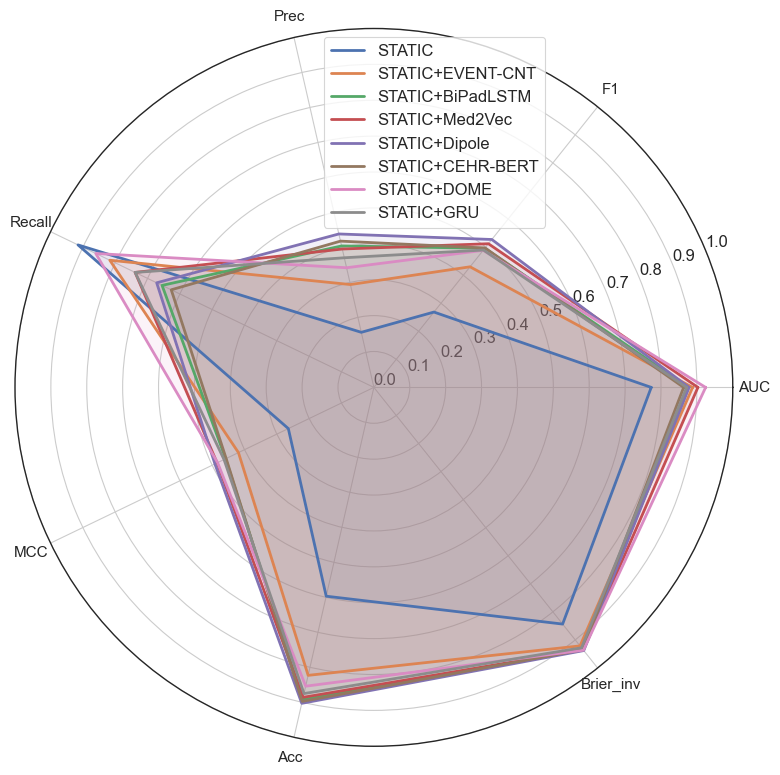

,AUC,F1,Prec,Recall,MCC,Acc,Brier,CM
Model,,,,,,,,
STATIC,0.773+0.034,0.268+0.014,0.157+0.009,0.915+0.053,0.265+0.026,0.597+0.026,0.156,"[[777.0, 589.0], [10.2, 109.8]]"
STATIC+EVENT-CNT,0.888+0.030,0.430+0.038,0.294+0.036,0.817+0.084,0.419+0.042,0.823+0.031,0.079,"[[1125.0, 241.0], [22.0, 98.0]]"
STATIC+BiPadLSTM,0.877+0.037,0.496+0.067,0.404+0.061,0.655+0.105,0.458+0.075,0.892+0.018,0.064,"[[1247.6, 118.4], [41.4, 78.6]]"
STATIC+Med2Vec,0.903+0.024,0.512+0.050,0.395+0.049,0.738+0.090,0.485+0.058,0.886+0.018,0.064,"[[1227.8, 138.2], [31.4, 88.6]]"
STATIC+Dipole,0.878+0.042,0.527+0.058,0.438+0.054,0.672+0.104,0.492+0.068,0.903+0.014,0.062,"[[1261.2, 104.8], [39.4, 80.6]]"
STATIC+CEHR-BERT,0.863+0.046,0.497+0.041,0.418+0.051,0.627+0.087,0.457+0.047,0.897+0.015,0.065,"[[1258.4, 107.6], [44.8, 75.2]]"
STATIC+DOME,0.924+0.025,0.488+0.033,0.342+0.029,0.860+0.066,0.483+0.039,0.854+0.016,0.063,"[[1165.8, 200.2], [16.8, 103.2]]"
STATIC+GRU,0.871+0.039,0.489+0.050,0.370+0.048,0.738+0.100,0.463+0.057,0.875+0.021,0.072,"[[1211.8, 154.2], [31.4, 88.6]]"


In [17]:
import pandas as pd
import numpy as np
from scripts.plotting import plot_radar

metrics = ["AUC", "F1", "Prec", "Recall", "MCC", "Acc",]
tmetrics = metrics + ['Brier', 'CM']
dfs = {}

for metric in tmetrics:
    print(f"& {metric} ", end='')
    dfs[metric] = pd.read_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv", index_col=0)
dfm = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfmp = pd.DataFrame(columns = tmetrics, index = dfs[metric].columns)
dfm.index.name = "Model"
dfmp.index.name = "Model"
for method in dfs[metric].columns:
    values = []
    valuesp = []
    for metric in tmetrics:
        if metric == "CM":
            cm = dfs[metric][method].apply(lambda x: np.array(eval(x))).sum() / 5
            values += [cm]
            valuesp += [cm]
        elif metric == 'Brier':
            values += [1 - dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}"]
        else:
            print(f"{dfs[metric][method].mean():.3f}$\pm${dfs[metric][method].std():.3f} & ", end="")
            values += [dfs[metric][method].mean()]
            valuesp += [f"{dfs[metric][method].mean():.3f}+{dfs[metric][method].std():.3f}"]
    dfm.loc[method] = values
    dfmp.loc[method] = valuesp
dfm.rename(columns={"Brier": "Brier_inv"}, inplace=True)
fig = plot_radar(dfm, metrics + ['Brier_inv'])
dfmp

## Plot calibaration curves

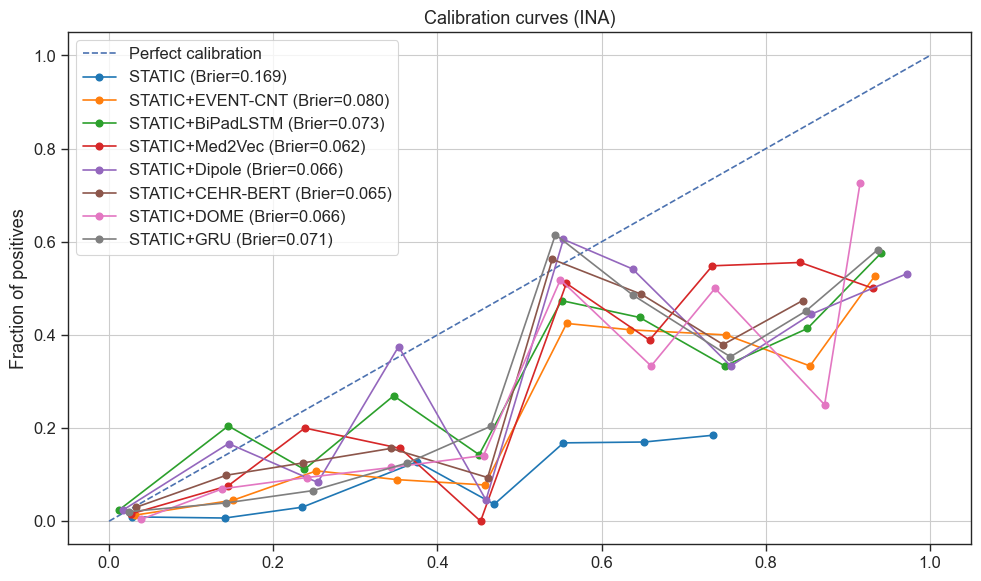

In [18]:
from scripts.plotting import plot_calibration
from scripts.utils import split_array
p_pred = {k:split_array(v)[0] for k,v in prob_pred.items()}
p_true = {k:list(v[0:len(p_pred[k])]) for k,v in prob_true.items()}
a_runs = {k:(v[0][0:1486], v[1][0:1486]) for k,v in all_runs.items()}
fig = plot_calibration(p_pred, p_true, a_runs,title=f"Calibration curves ({dataset})")